In [1]:
pip install miditok


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.0/159.0 kB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 81.4 MB/s eta 0:00:00


In [2]:
pip install torch

In [3]:
pip install music21

In [4]:
pip install librosa pydub midi2audio IPython


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 128.3 MB/s eta 0:00:00


In [ ]:
import os
os.environ["XLA_MODEL_PARALLEL"] = "1"

In [1]:
import torch

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
from miditok import REMI, TokenizerConfig
from miditok.utils import split_files_for_training
from miditok.pytorch_data import DatasetMIDI, DataCollator
from torch.utils.data import DataLoader
from pathlib import Path

from miditok import REMI
tokenizer = REMI(params="/content/MIDI-LSTM-and-transformer-decoder/trained_tokenizer/tokenizer_final.json")


/usr/local/lib/python3.12/dist-packages/miditok/tokenizations/remi.py:88: UserWarning: Attribute controls are not compatible with 'config.one_token_stream_for_programs' and multi-vocabulary tokenizers. Disabling them from the config.
  super().__init__(tokenizer_config, params)


In [4]:
tokenizer.vocab_size


5000

In [5]:
import zipfile
import os

def extract_datasets(zip_path,extract_path):
  with zipfile.ZipFile(zip_path, 'r') as zip_ref:
      erro = zip_ref.testzip()
      return zip_ref.extractall(extract_path)

In [6]:
training_unziped = extract_datasets("/content/MIDI-LSTM-and-transformer-decoder/features/dataset_training.zip","/content/dataset_training")

test_unziped = extract_datasets("/content/MIDI-LSTM-and-transformer-decoder/features/dataset_test.zip","/content/dataset_test")

validation_unziped = extract_datasets("/content/MIDI-LSTM-and-transformer-decoder/features/dataset_validation.zip","/content/dataset_validation")


In [7]:
training_path = list(Path("/content/dataset_training").glob("**/*.mid"))
validation_path = list(Path("/content/dataset_validation").glob("**/*.mid"))
test_path = list(Path("/content/dataset_test").glob("**/*.mid"))


In [8]:
print(len(training_path))
print(len(validation_path))
print(len(test_path))

15175
5951
2678


In [9]:
dataset_chunks_dir = Path("/content/training_chunked")

In [25]:
max_seq_len = 1024
batch_size = 64
hidden_dim = 512
epochs = 15
embed_dim = 512
num_layers = 2
name_model = "pesos_lstm.pt"
version=6
complete_path = f"/content/MIDI-LSTM-and-transformer-decoder/training/tokenizer_novo/{version}/"

In [11]:
# Split MIDIs into smaller chunks for training
split_files_for_training(
    files_paths=training_path,
    tokenizer=tokenizer,
    save_dir=dataset_chunks_dir,
    max_seq_len=max_seq_len,
)
print(split_files_for_training) #512, 1024, or 2048 tokens

Splitting music files (/content/training_chunked): 100%|██████████| 15175/15175 [00:37<00:00, 407.72it/s]

<function split_files_for_training at 0x7a17e032b420>


In [13]:
dataset_training = DatasetMIDI(
    files_paths=list(dataset_chunks_dir.glob("**/*.mid")),
    tokenizer=tokenizer,
    max_seq_len=max_seq_len,
    bos_token_id=tokenizer["BOS_None"],
    eos_token_id=tokenizer["EOS_None"],
)
print(dataset_training)

68777 files.


In [14]:
dataset_validation = DatasetMIDI(
    files_paths=validation_path,
    tokenizer=tokenizer,
    max_seq_len=max_seq_len,
    bos_token_id=tokenizer["BOS_None"],
    eos_token_id=tokenizer["EOS_None"],
)
print(dataset_validation)

5951 files.


In [15]:
dataset_test = DatasetMIDI(
    files_paths=test_path,
    tokenizer=tokenizer,
    max_seq_len=max_seq_len,
    bos_token_id=tokenizer["BOS_None"],
    eos_token_id=tokenizer["EOS_None"],
)
print(dataset_test)

2678 files.


In [16]:
collator = DataCollator(tokenizer.pad_token_id, copy_inputs_as_labels=True, shift_labels=True)


In [17]:
dataloader_validation = DataLoader(dataset_validation, batch_size=batch_size,num_workers=0, persistent_workers=False, collate_fn=collator,drop_last=True)

dataloader_test = DataLoader(dataset_test, batch_size=60, collate_fn=collator)

In [18]:
import random

def generate_sample_input_predict(dataloader_test):
  valor=random.randint(1, len(dataloader_test))
  counter = 1
  for batch in dataloader_test:
    if counter == valor:
      return batch["input_ids"]
    counter=counter+1

In [20]:
import torch
import torch.nn as nn

class MusicGeneratorLSTM(nn.Module):
    def __init__(self, vocab_size,embed_dim,hidden_dim,num_layers):
        super().__init__()
        self.num_layers = num_layers
        self.hidden_dim = hidden_dim
        self.embedding = nn.Embedding(vocab_size,embed_dim)
        self.lstm = nn.LSTM(input_size=embed_dim, hidden_size=hidden_dim, num_layers=num_layers, batch_first=True,dropout=0.2)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden=None):
        if hidden is None:
            batch_size = x.size(0)
            device = x.device
            hidden = (
                torch.zeros(self.num_layers, batch_size, self.hidden_dim, device=device),
                torch.zeros(self.num_layers, batch_size, self.hidden_dim, device=device)
            )

        x = self.embedding(x)
        out, hidden = self.lstm(x, hidden)
        out = self.fc(out)
        return out, hidden

In [21]:
from pathlib import Path

def converte_output_to_midi(lstm_output, name):
  lstm_output.dump_midi(Path(f"{name}.mid"))


In [22]:
from music21 import converter

def tonal_estimator(music):
  score = converter.parse(music)
  key = score.analyze("key")

  print(key)
  print(f"Tônica: {key.tonic.name} e modo: {key.mode}")
  print(f"Consistência tonal: {key.correlationCoefficient}")
  print(f"Melhor tonalidade: {key.tonalCertainty()}")

In [23]:
from collections import defaultdict
import matplotlib.pyplot as plt
import librosa

def counter_notes(music):
  counter_bar = defaultdict(int)
  counter_pitch = defaultdict(int)
  counter_velocity = defaultdict(int)

  for token in music:
    if "bar" in token.lower():
      counter_bar["bar"] += 1
    #altura das notas
    if "velocity" in token.lower():
      velocity = int(token.split("_")[1])
      counter_velocity[velocity] += 1
    # Quando encontra um Pitch (Note On)
    elif "pitch" in token.lower():
        pitch_val = int(token.split("_")[1])
        pitch_note = librosa.midi_to_note(pitch_val)
        counter_pitch[pitch_note] += 1

  plt.figure(figsize=(20, 10))
  majors_pitch = sorted(counter_pitch.items(), key=lambda x: x[1], reverse=True)
  majors_velocity = sorted(counter_velocity.items(), key=lambda x: x[1], reverse=True)

  x_pitch,y_pitch = zip(*majors_pitch)
  plt.bar(x_pitch,y_pitch, color='skyblue')

  plt.title('Notas mais tocadas')
  plt.xlabel('Notas')
  plt.ylabel('Quantidade')

  plt.show()
  print("\n \n \n")
  x_vel,y_vel = zip(*majors_velocity)
  plt.bar(x_vel,y_vel, color='skyblue')

  plt.title('Altura mais tocadas')
  plt.xlabel('Altura')
  plt.ylabel('Quantidade')

  plt.show()

  print("\n \n \n")

  print(f"Quantidade compassos: {counter_bar["bar"]}")


In [ ]:
dataloader_training = DataLoader(
  dataset_training,
  batch_size=batch_size,
  num_workers=4,
  pin_memory=False,
  persistent_workers=True,
  prefetch_factor=4,
  collate_fn=collator,
  drop_last=True
)
model = MusicGeneratorLSTM(vocab_size=tokenizer.vocab_size, embed_dim=embed_dim, hidden_dim=hidden_dim, num_layers=num_layers).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(),lr=0.001)

list_epoch_loss = []
list_perplexity = []
print(f"Tamanho do lote de treinamento: {len(dataloader_training)}",flush=True)
print(f"Tamanho da época: {epochs}",flush=True)

Path(complete_path).mkdir(parents=True, exist_ok=True)

for epoch in range(epochs):
    loss_valores_cpu = []

    hidden_train = (
        torch.zeros(num_layers, batch_size, hidden_dim, device=device),
        torch.zeros(num_layers, batch_size, hidden_dim, device=device)
    )

    cont = 0
    for batch in dataloader_training:
        optimizer.zero_grad()
        if isinstance(hidden_train, tuple):
            hidden_train = (hidden_train[0].detach(), hidden_train[1].detach())

        inputs = batch["input_ids"].to(device)
        targets = batch["labels"].to(device)

        outputs, hidden_train = model(inputs, hidden_train)
        loss = criterion(outputs.reshape(-1, tokenizer.vocab_size), targets.reshape(-1))
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        loss_valores_cpu.append(loss.item())
        cont += 1
        print(f"Lote processado: {cont}", flush=True)

    loss_final = sum(loss_valores_cpu) / len(loss_valores_cpu) if loss_valores_cpu else 0.0
    perplexity = torch.exp(torch.tensor(loss_final)).item()

    list_epoch_loss.append(loss_final)
    list_perplexity.append(perplexity)

    print(f"contador total de lotes: {cont}", flush=True)
    print(f"Finalizando época: {epoch} de treinamento com loss: {loss_final:.4f}", flush=True)
    print(f"Finalizando época: {epoch} de treinamento com perplexidade: {perplexity:.4f}", flush=True)
checkpoint = {
    'model_state_dict': model.state_dict(),
    'train_loss': list_epoch_loss,
    'train_perplexity': list_perplexity
}
torch.save(checkpoint, str(Path(complete_path) / name_model))


Streaming output truncated to the last 5000 lines.
Lote processado: 386
Lote processado: 387
Lote processado: 388
Lote processado: 389
Lote processado: 390
Lote processado: 391
Lote processado: 392
Lote processado: 393
Lote processado: 394
Lote processado: 395
Lote processado: 396
Lote processado: 397
Lote processado: 398
Lote processado: 399
Lote processado: 400
Lote processado: 401
Lote processado: 402
Lote processado: 403
Lote processado: 404
Lote processado: 405
Lote processado: 406
Lote processado: 407
Lote processado: 408
Lote processado: 409
Lote processado: 410
Lote processado: 411
Lote processado: 412
Lote processado: 413
Lote processado: 414
Lote processado: 415
Lote processado: 416
Lote processado: 417
Lote processado: 418
Lote processado: 419
Lote processado: 420
Lote processado: 421
Lote processado: 422
Lote processado: 423
Lote processado: 424
Lote processado: 425
Lote processado: 426
Lote processado: 427
Lote processado: 428
Lote processado: 429
Lote processado: 430
Lote

In [27]:
path_model = f"{complete_path}{name_model}"

path_music = f"{complete_path}music-{version}"

In [75]:
device_test = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [28]:
path_model = f"{complete_path}{name_model}"
model_t_v = MusicGeneratorLSTM(vocab_size=tokenizer.vocab_size, embed_dim=embed_dim, hidden_dim=hidden_dim, num_layers=num_layers)
state_dict = torch.load(path_model,map_location=device)
res = model_t_v.load_state_dict(state_dict['model_state_dict'], strict=True)
loss_training = state_dict['train_loss']
perplexity_training = state_dict['train_perplexity']
print(res)
model_t_v.to(device)
model_t_v.eval()


<All keys matched successfully>


MusicGeneratorLSTM(
  (embedding): Embedding(5000, 512)
  (lstm): LSTM(512, 512, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=512, out_features=5000, bias=True)
)

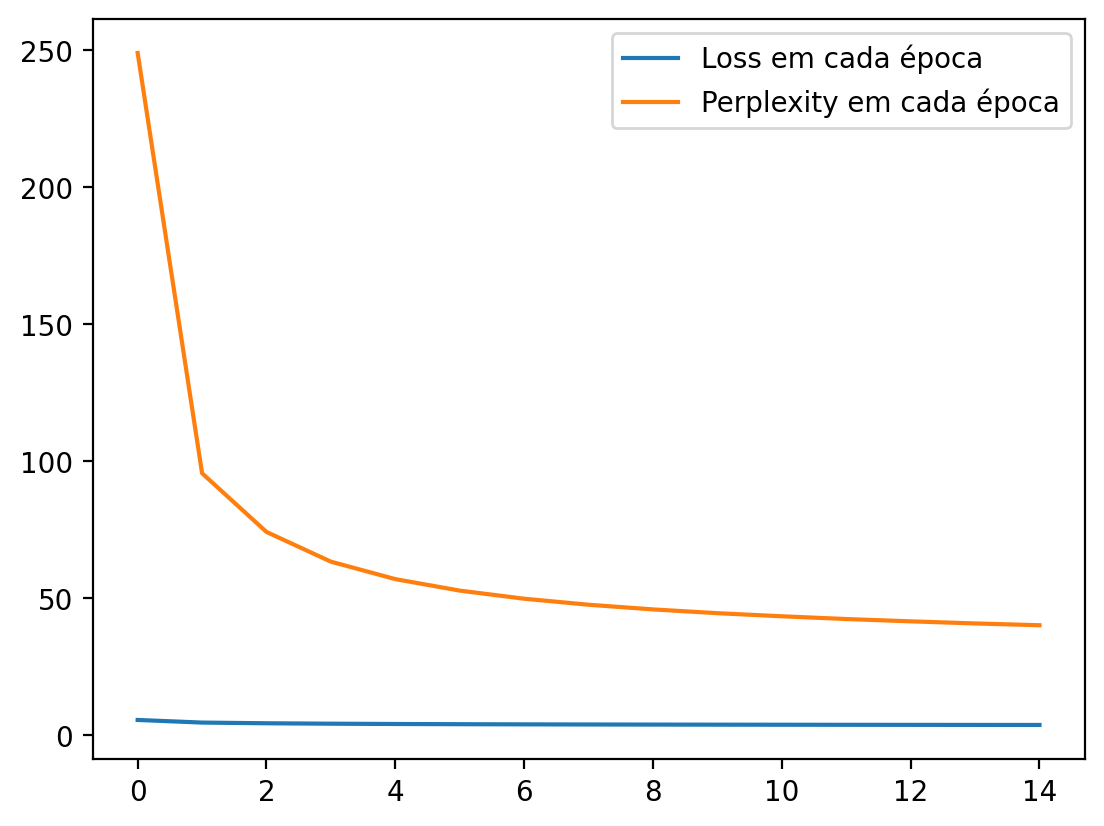

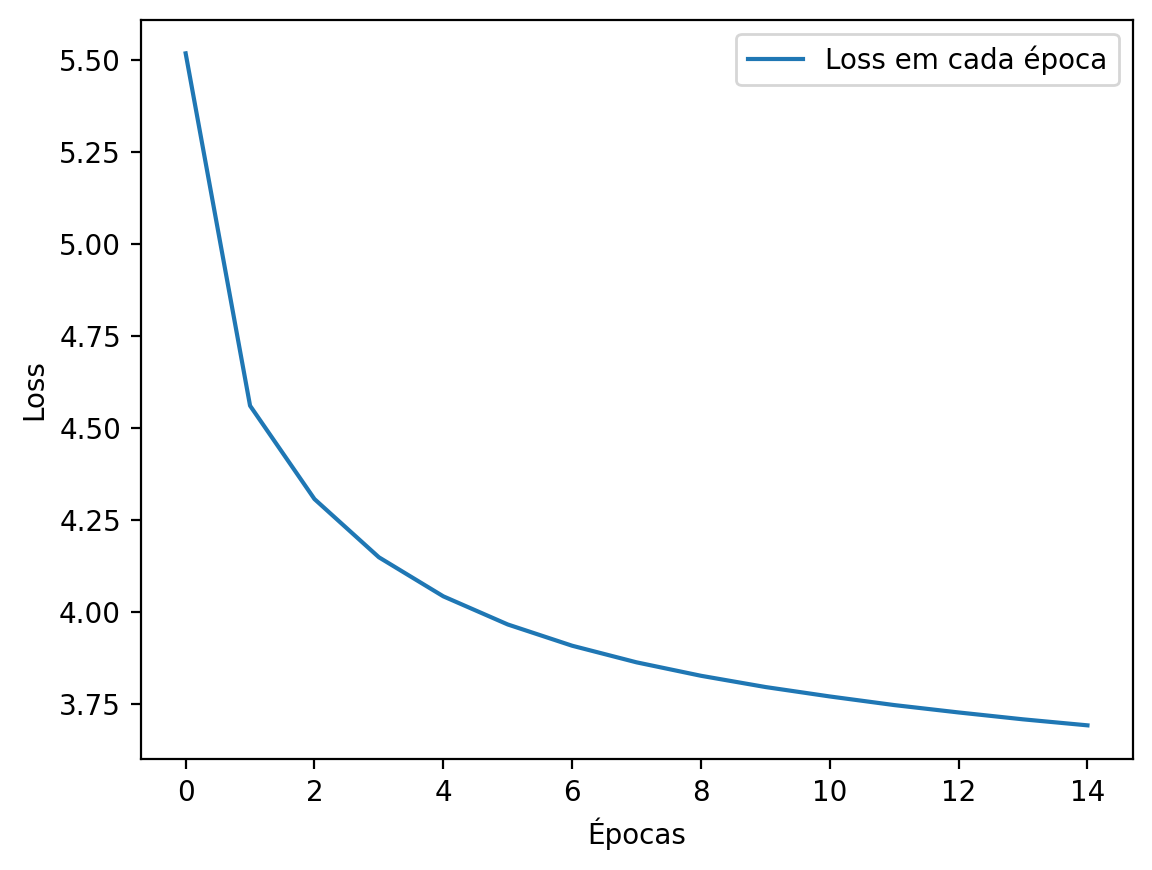

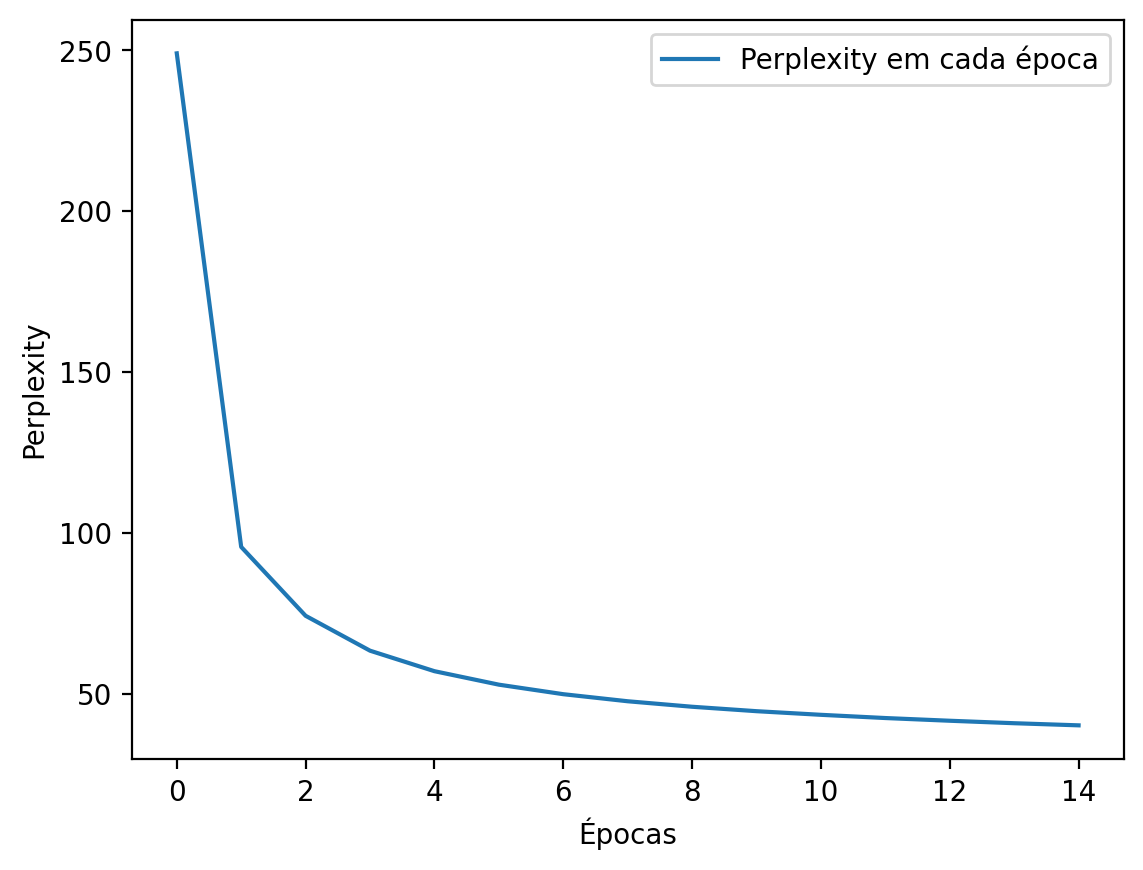

In [29]:
import matplotlib.pyplot as plt
lista_epochs = [i for i in range(epochs)]

# Plota cada lista com um rótulo (label)
plt.plot(lista_epochs, loss_training, label='Loss em cada época')
plt.plot(lista_epochs, perplexity_training, label='Perplexity em cada época')


# Adiciona título, legenda e exibe
plt.legend()
plt.show()

print("\n \n \n")

# Plota cada lista com um rótulo (label)
plt.plot(lista_epochs, loss_training, label='Loss em cada época')


# Adiciona título, legenda e exibe
plt.legend()
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.show()

print("\n \n \n")
# Plota cada lista com um rótulo (label)
plt.plot(lista_epochs, perplexity_training, label='Perplexity em cada época')


# Adiciona título, legenda e exibe
plt.legend()
plt.xlabel('Épocas')
plt.ylabel('Perplexity')
plt.show()


In [30]:
total_loss = 0.0
ac = 0.0
criterion = nn.CrossEntropyLoss()
batch_len = 0
with torch.no_grad():
    hidden_validation = None
    for batch in dataloader_validation:
        if hidden_validation is not None:
            hidden_validation = (hidden_validation[0].detach(), hidden_validation[1].detach())
        inputs = batch["input_ids"].to(device)
        targets = batch["labels"].to(device)

        outputs, hidden_validation = model_t_v(inputs, hidden_validation)
        target_reshaped = targets.reshape(-1)
        loss = criterion(outputs.reshape(-1, tokenizer.vocab_size), target_reshaped)
        total_loss += loss.item()
        predicted = outputs.argmax(dim=-1).reshape(-1)
        ac += ((predicted==target_reshaped).sum().item()) / target_reshaped.size(0)

mean_loss = total_loss / len(dataloader_validation)
print(f"Perda média na validação: {mean_loss}")

mean_loss_tensor = torch.tensor(mean_loss)

perplexity_validation = torch.exp(mean_loss_tensor)
print(f"Perplexidade na validação: {perplexity_validation.item()}")

perplexity_validation = torch.exp(mean_loss_tensor)
print(f"Acurácia na validação: {ac}")

Perda média na validação: 3.7005461661711982
Perplexidade na validação: 40.46940612792969
Acurácia na validação: 16.075520444765505


In [31]:
def make_prediction(model, dataloader_test, steps=0):
  inputs = generate_sample_input_predict(dataloader_test)
  hidden = None
  for _ in range(steps):
    with torch.no_grad():
      outputs, hidden = model(inputs.to(device), hidden)
      next_token_tensor = outputs[:, -1, :].argmax(-1,keepdim=True)
      inputs = torch.cat([inputs.to(device), next_token_tensor],dim=1)
  return inputs[0]



In [32]:
music_predicted = make_prediction(model_t_v, dataloader_test, steps=100)

In [33]:
music_decoded = tokenizer(music_predicted.squeeze().tolist())
print(music_decoded)

Score(ttype=Tick, tpq=8, begin=0, end=1165, tracks=1, notes=690, time_sig=1, key_sig=0, markers=0)


In [34]:
midi = tokenizer(music_decoded)
print(midi)

TokSequence(tokens=['Bar_None', 'TimeSig_4/4', 'Position_0', 'Tempo_121.29', 'Bar_None', 'TimeSig_4/4', 'Position_1', 'Program_0', 'Pitch_36', 'Velocity_59', 'Duration_0.1.8', 'Position_2', 'Program_0', 'Pitch_48', 'Velocity_59', 'Duration_0.1.8', 'Position_9', 'Program_0', 'Pitch_60', 'Velocity_55', 'Duration_0.4.8', 'Program_0', 'Pitch_51', 'Velocity_51', 'Duration_0.4.8', 'Program_0', 'Pitch_55', 'Velocity_55', 'Duration_0.4.8', 'Position_14', 'Program_0', 'Pitch_55', 'Velocity_19', 'Duration_0.1.8', 'Position_16', 'Program_0', 'Pitch_41', 'Velocity_51', 'Duration_0.1.8', 'Program_0', 'Pitch_56', 'Velocity_59', 'Duration_0.1.8', 'Position_17', 'Program_0', 'Pitch_60', 'Velocity_39', 'Duration_0.1.8', 'Program_0', 'Pitch_53', 'Velocity_51', 'Duration_0.1.8', 'Position_19', 'Program_0', 'Pitch_60', 'Velocity_55', 'Duration_0.1.8', 'Position_20', 'Program_0', 'Pitch_51', 'Velocity_59', 'Duration_0.1.8', 'Program_0', 'Pitch_55', 'Velocity_55', 'Duration_0.1.8', 'Position_24', 'Program_0

In [35]:
music_to_midi = converte_output_to_midi(music_decoded, path_music)
print(music_decoded)

Score(ttype=Tick, tpq=8, begin=0, end=1165, tracks=1, notes=690, time_sig=1, key_sig=0, markers=0)


In [36]:
tonal_estimator(f"{path_music}.mid")

c minor
Tônica: C e modo: minor
Consistência tonal: 0.8800536589826835
Melhor tonalidade: 1.4103305985786883


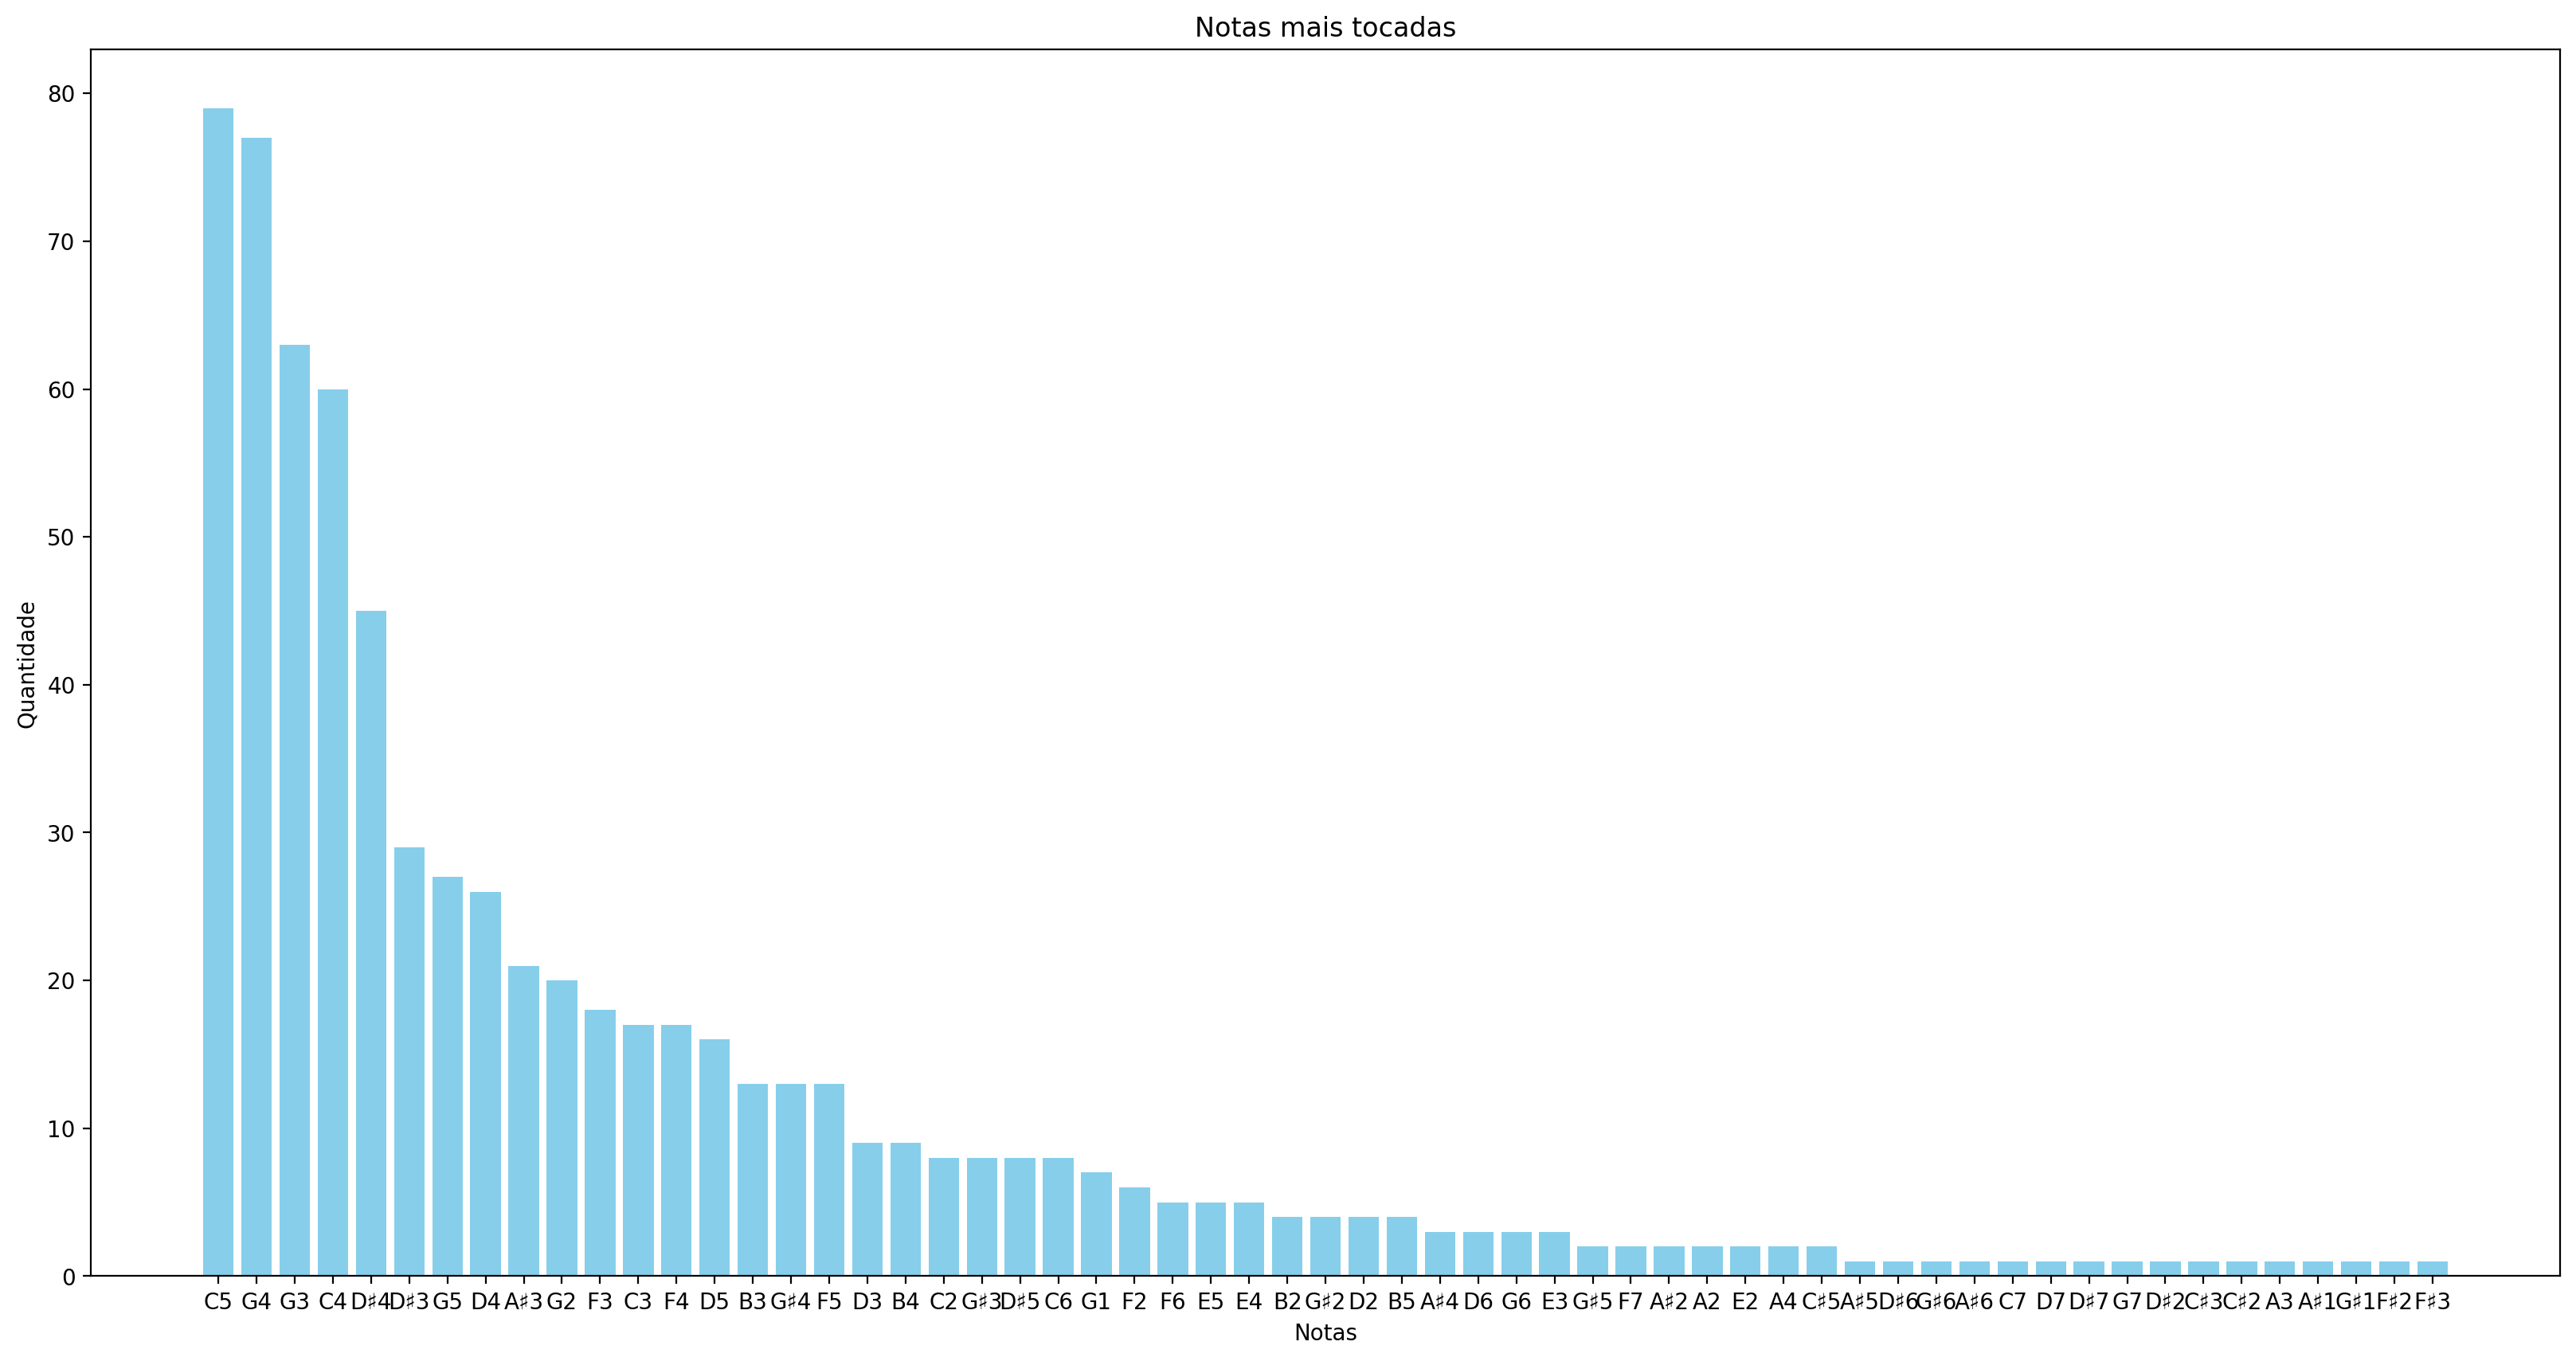

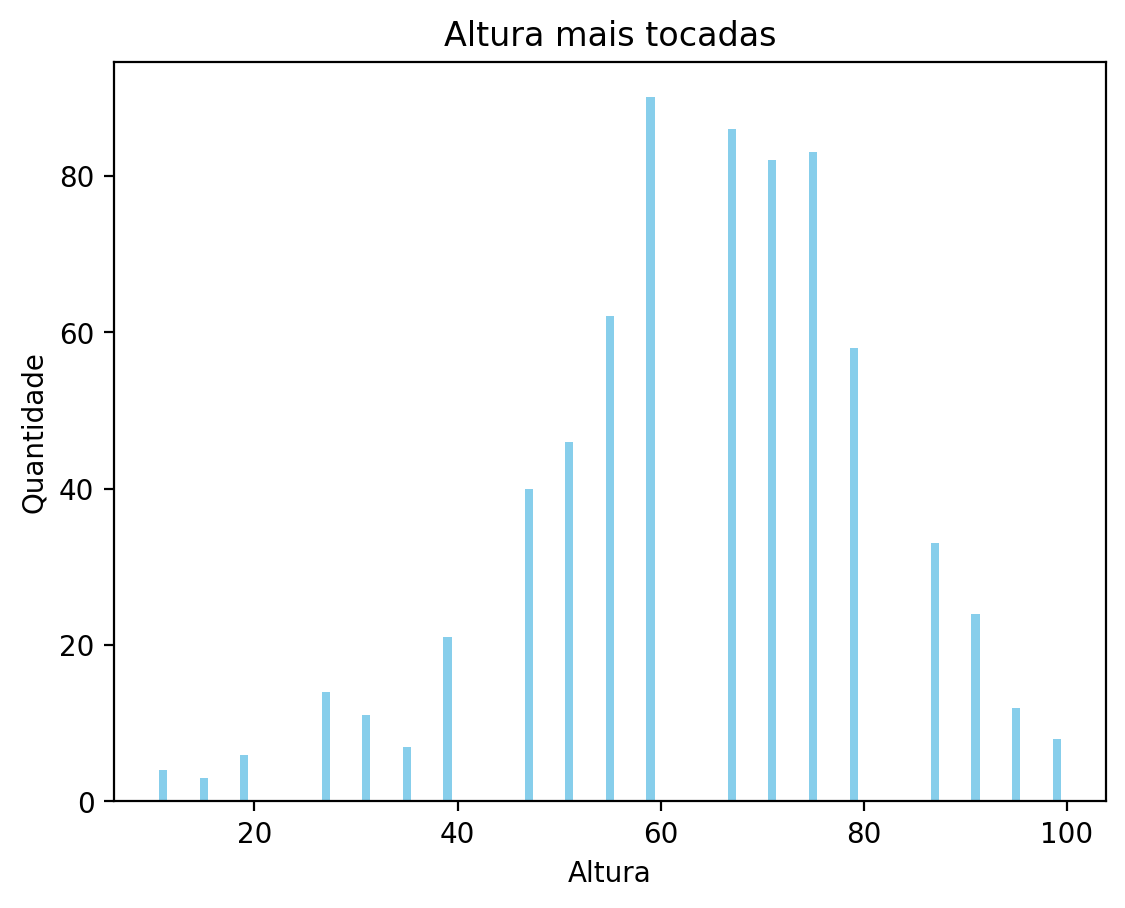


 
 

Quantidade compassos: 37


In [37]:
counter_notes(midi.tokens)